# Import Packages

In [ ]:
!pip install --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 21.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


# Import Libraries

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt

from numba import njit
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import least_squares
from scipy.signal import detrend, savgol_filter

import os

import seaborn as sns

THEANO_FLAGS = "optimizer=fast_compile"

print(f"PyMC3 Version: {pm.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"PyTensor Version: {pytensor.__version__}")

PyMC3 Version: 5.21.2
NumPy Version: 1.26.4
PyTensor Version: 2.30.2


# Import Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


# Transform Data

<Axes: xlabel='time'>

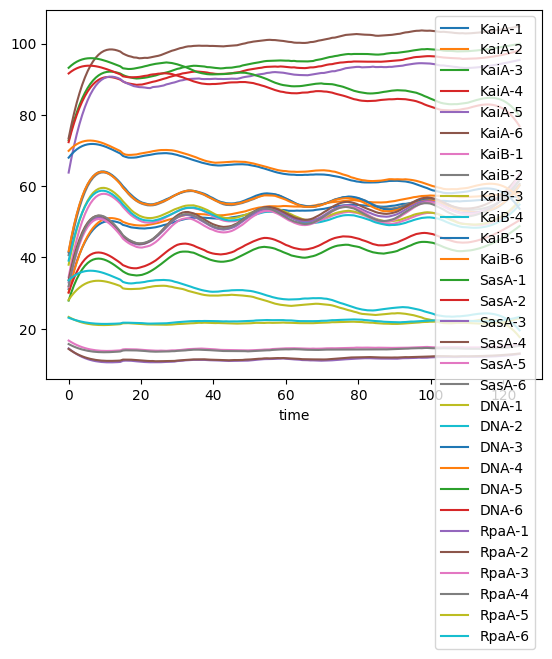

In [ ]:
dinner_smooth = dinner_df.copy()

dinner_smooth = dinner_smooth.iloc[::3, :]

window_length = 40
polyorder = 3

dinner_smooth.iloc[:, 1:] = savgol_filter(x = dinner_smooth.iloc[:, 1:].T,
                                          window_length = window_length,
                                          polyorder = polyorder).T

dinner_smooth = np.trunc(dinner_smooth * 1000) / 1000

dinner_smooth.plot(x = 'time')

# Sampling

## Sampling Plots

<Axes: xlabel='time'>

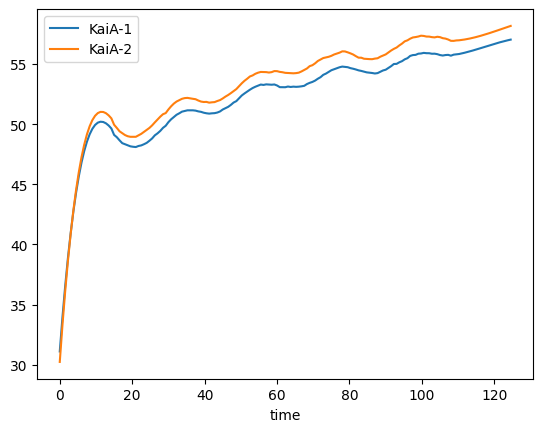

In [ ]:
dinner_smooth[['time', 'KaiA-1', 'KaiA-2']].plot(x = 'time')

<Axes: xlabel='time'>

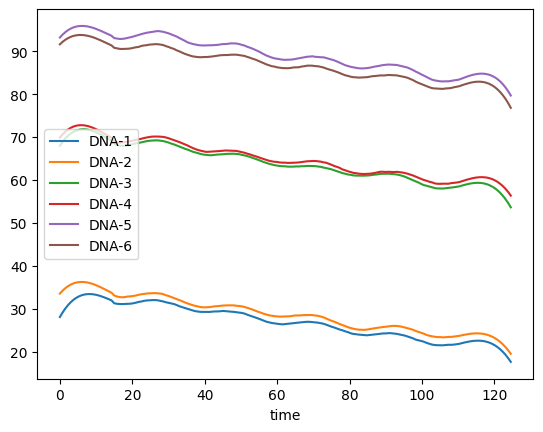

In [ ]:
dinner_smooth[['time'] + [f'DNA-{i}' for i in range(1, 7)]].plot(x = 'time')

<Axes: xlabel='time'>

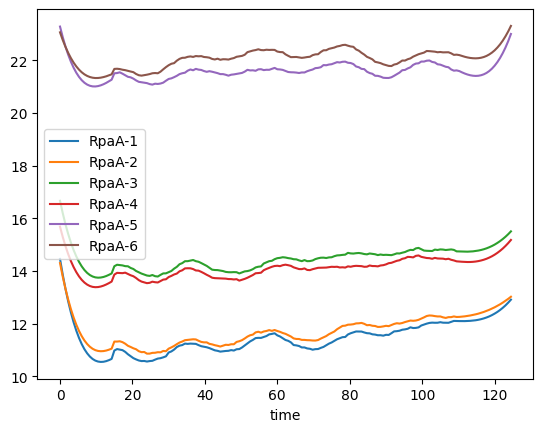

In [ ]:
dinner_smooth[['time'] + [f'RpaA-{i}' for i in range(1, 7)]].plot(x = 'time')

<Axes: xlabel='time'>

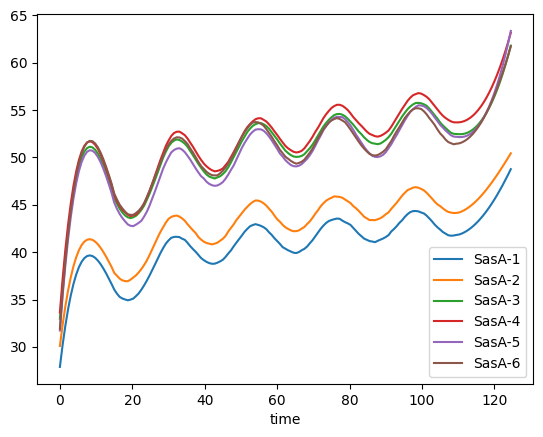

In [ ]:
dinner_smooth[['time'] + [f'SasA-{i}' for i in range(1, 7)]].plot(x = 'time')

<Axes: xlabel='time'>

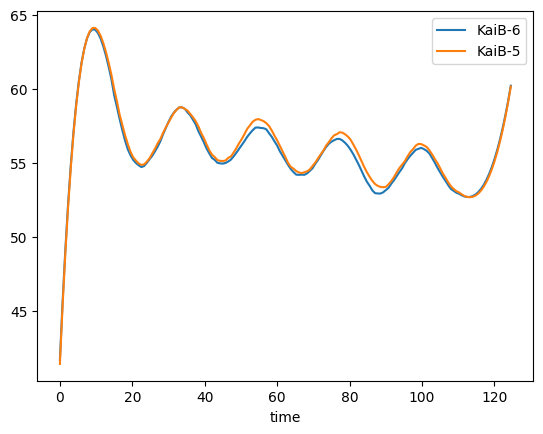

In [ ]:
dinner_smooth[['time', 'KaiB-6', 'KaiB-5']].plot(x = 'time')

<Axes: xlabel='time'>

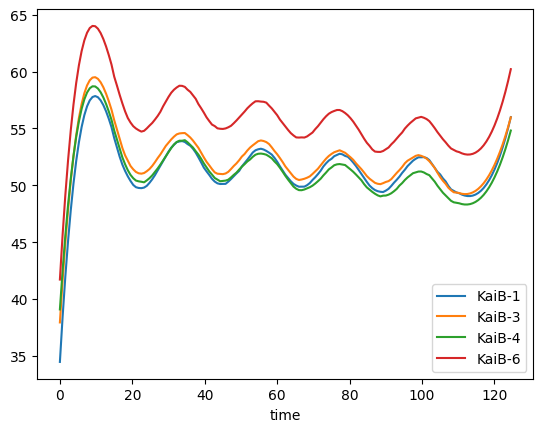

In [ ]:
dinner_smooth[['time', 'KaiB-1', 'KaiB-3', 'KaiB-4', ]].plot(x = 'time')

<Axes: xlabel='time'>

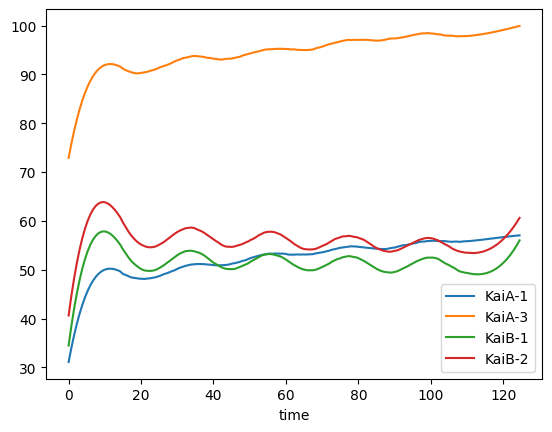

In [ ]:
dinner_smooth[['time', 'KaiA-1', 'KaiA-3', 'KaiB-1', 'KaiB-2']].plot(x = 'time')

## Sampling Code

<Axes: xlabel='time'>

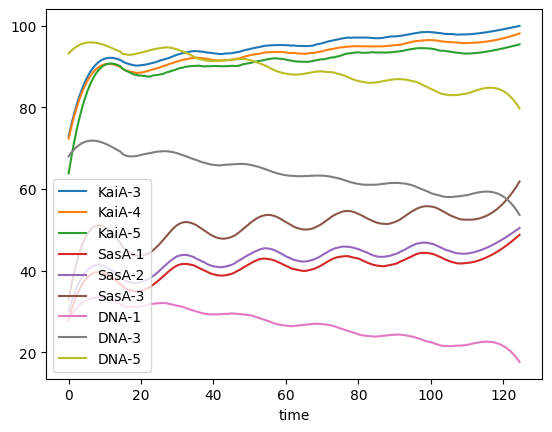

In [ ]:
dinner_sampled = dinner_smooth[['time', 'KaiA-3', 'KaiA-4', 'KaiA-5',
                                'SasA-1', 'SasA-2', 'SasA-3',
                                'DNA-1', 'DNA-3', 'DNA-5']]
                                #, 'RpaA-1', 'RpaA-3', 'RpaA-5']]
dinner_sampled.plot(x = 'time')

# Helper Functions

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dmatrix], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0 = theta[0, :]
    r = theta[1, :]
    AX = theta[2, :]
    B = theta[3, :]

    return odeint(func=gLV, y0=X0,
                  t=dinner_smooth.time,
                  args=(r, AX, B))



def gLV(X, t, r, AX, B):
    return X * (r + AX) + B

# Specify Model

In [ ]:
dinner_sampled.iloc[1, 1:].values.shape

(9,)

In [ ]:
# theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
n = dinner_smooth.shape[1] - 1
with pm.Model() as model:

    priors = []

    # Params for X0
    X0 = pm.Uniform("X0",
                    lower=0,
                    upper=120,
                    shape=n,
                    initval=dinner_smooth.iloc[1, 1:].values)
    priors.append(X0)

    # Params for r
    r = pm.Normal("r",
                  mu=0,
                  sigma=2,
                  shape=n)
    priors.append(r)


    # Params for A
    A = pm.Normal("A",
                  mu=0,
                  sigma=5,
                  shape=(n, n))

    AX = pm.Deterministic(name = "AX", var = pm.math.dot(A, X0))
    priors.append(AX)

    # Params for linear term B
    B = pm.Normal("B",
                  mu=0,
                  sigma=5,
                  shape=n)
    priors.append(B)

    # Priors
    sigma = pm.HalfNormal("sigma", 2)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dinner_smooth.iloc[:, 1:].values)

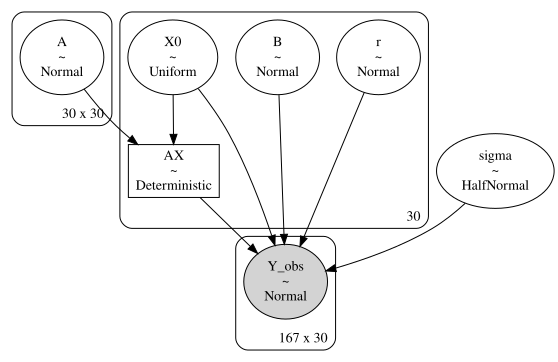

In [ ]:
pm.model_to_graphviz(model)

# Bayesian Inference Sampling (Independent Normal Dists)

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(step=[pm.Metropolis(vars_list)],
                            draws=draws,
                            progressbar = True)

trace = trace_slice
az_trace = az.summary(trace)
az_trace

Output()

/usr/local/lib/python3.11/dist-packages/pymc/step_methods/metropolis.py:320: RuntimeWarning: overflow encountered 
in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),

<ipython-input-6-fd125b6e4c76>:18: RuntimeWarning: overflow encountered in multiply
  return X * (r + AX) + B

<ipython-input-6-fd125b6e4c76>:11: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1
to get quantitative information.
  return odeint(func=gLV, y0=X0,

<ipython-input-6-fd125b6e4c76>:11: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with
full_output = 1 to get quantitative information.
  return odeint(func=gLV, y0=X0,

<ipython-input-6-fd125b6e4c76>:11: ODEintWarning: Excess accuracy requested (tolerances too small). Run with 
full_output = 1 to get quantitative information.
  return odeint(func=gLV, y0=X0,

<ipython-input-6-fd125b6e4c76>:18: RuntimeWarning: invalid value encountered in multiply
  return X * (r + AX) + B

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A[0, 0]",0.000,0.000,-0.000,0.000,0.000,0.000,2.0,7.0,2.55
"A[0, 1]",-0.000,0.000,-0.000,0.000,0.000,0.000,2.0,10.0,2.41
"A[0, 2]",-0.000,0.000,-0.000,0.000,0.000,0.000,3.0,21.0,1.94
"A[0, 3]",-0.000,0.000,-0.000,0.000,0.000,0.000,3.0,20.0,2.00
"A[0, 4]",0.000,0.000,-0.000,0.000,0.000,0.000,2.0,16.0,2.50
...,...,...,...,...,...,...,...,...,...
r[26],-0.001,0.002,-0.004,0.002,0.002,0.000,3.0,20.0,2.29
r[27],0.000,0.001,-0.002,0.003,0.001,0.000,3.0,20.0,1.71
r[28],-0.001,0.003,-0.004,0.003,0.002,0.000,3.0,25.0,1.96
r[29],0.000,0.001,-0.001,0.002,0.001,0.000,3.0,23.0,1.80


In [ ]:
A_mh

array([[ 0.,  0., -0.,  0.,  0., -0., -0., -0.,  0.,  0.,  0.,  0.],
       [ 0., -0.,  0.,  0., -0.,  0., -0.,  0.,  0.,  0., -0.,  0.],
       [-0.,  0., -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0.,  0., -0.,  0., -0., -0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -0.,  0.,  0.,  0.,  0., -0.,  0., -0.,  0.],
       [ 0.,  0., -0.,  0., -0., -0.,  0., -0.,  0.,  0.,  0., -0.],
       [ 0.,  0., -0., -0., -0.,  0., -0.,  0., -0., -0.,  0., -0.],
       [ 0., -0., -0.,  0.,  0., -0., -0.,  0.,  0.,  0., -0., -0.],
       [-0., -0.,  0., -0.,  0., -0., -0., -0.,  0., -0., -0.,  0.],
       [ 0., -0.,  0., -0.,  0.,  0., -0.,  0., -0.,  0., -0.,  0.],
       [ 0.,  0., -0.,  0., -0.,  0., -0., -0.,  0.,  0.,  0.,  0.],
       [ 0., -0., -0., -0.,  0., -0., -0., -0.,  0., -0.,  0.,  0.]])

In [ ]:
A_mh = az_trace['mean'].iloc[:12 * 12].values.reshape((12, 12))
X0_mh = az_trace['mean'].iloc[12 * 12 + 12:12 * 12 + 12 * 2]
r_mh = az_trace['mean'].iloc[12 * 12 + 12 * 2:12 * 12 + 12 * 3]

In [ ]:
gLV(X0_mh, 0, r_mh, A_mh * X0_mh)

ValueError: Data must be 1-dimensional, got ndarray of shape (12, 12) instead

# Sample on Multivariate Normal + LKJ Prior

In [ ]:
# theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
n = dinner_sampled.shape[1] - 1
with pm.Model() as model:

    priors = []

    # Params for X0
    X0 = pm.Uniform("X0",
                    lower=0,
                    upper=120,
                    shape=n,
                    initval=dinner_sampled.iloc[1, 1:].values)
    priors.append(X0)

    # Params for r
    r = pm.Normal("r",
                  mu=0,
                  sigma=2,
                  shape=n)
    priors.append(r)


    # Params for A
    mu_group = pm.Normal("A_mu", mu=dinner_sampled.iloc[:, 1:].mean().values, sigma=1, shape=n)

    sd_dist = pm.Exponential.dist(1, shape=n)
    chol, _, _ = pm.LKJCholeskyCov(
            "A_chol",
            n=n,
            eta=2,
            sd_dist=sd_dist,
            compute_corr=True,
            store_in_trace=False,
    )
    cov = pm.Deterministic(f"A_cov", chol.dot(chol.T))

    A = pm.MvNormal(name = "A",
                    mu=mu_group,
                    chol=chol,
                    initval=dinner_sampled.iloc[:, 1:].cov().values,
                    shape=(n, n))

    AX = pm.Deterministic(name = "AX", var = pm.math.dot(A, X0))
    priors.append(AX)

    # Params for linear term B
    B = pm.Normal("B",
                  mu=0,
                  sigma=5,
                  shape=n)
    priors.append(B)

    # Priors
    sigma = pm.HalfNormal("sigma", 2)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dinner_sampled.iloc[:, 1:].values)

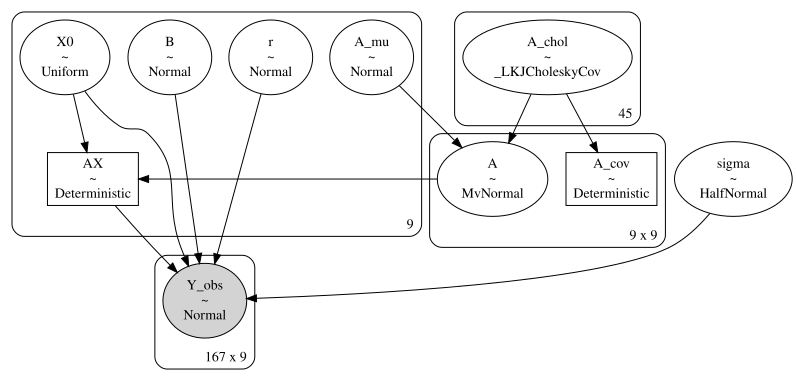

In [ ]:
pm.model_to_graphviz(model)

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(step=[pm.Metropolis(vars_list)],
                            draws=draws,
                            tune=tune,
                            progressbar = True,
                            nuts_sampler = 'pymc')

trace = trace_slice
az_trace = az.summary(trace)
az_trace

 Progress                          Draws   Tuning   Scaling   Accept Rate   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000    False    0.00      nan           1.53 draws/s     0:21:49   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000    False    0.00      nan           1.30 s/draws     0:43:27   0:00:00

/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_s

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A[0, 0]",17.451,0.0,17.451,17.451,0.0,0.0,2000.0,2000.0,NaN
"A[0, 1]",16.153,0.0,16.153,16.153,0.0,0.0,2000.0,2000.0,NaN
"A[0, 2]",17.730,0.0,17.730,17.730,0.0,0.0,2000.0,2000.0,NaN
"A[0, 3]",11.511,0.0,11.511,11.511,0.0,0.0,2000.0,2000.0,NaN
"A[0, 4]",11.981,0.0,11.981,11.981,0.0,NaN,2000.0,2000.0,NaN
...,...,...,...,...,...,...,...,...,...
r[5],0.000,0.0,0.000,0.000,0.0,NaN,2000.0,2000.0,NaN
r[6],0.000,0.0,0.000,0.000,0.0,NaN,2000.0,2000.0,NaN
r[7],0.000,0.0,0.000,0.000,0.0,NaN,2000.0,2000.0,NaN
r[8],0.000,0.0,0.000,0.000,0.0,NaN,2000.0,2000.0,NaN


In [ ]:
az_trace.to_csv(os.path.join(data_path, "dinner/dinner_trace_mvnormal.csv"))

In [ ]:
A_mh = az_trace.loc[az_trace['mean'].index.str.startswith('A['), 'mean'].values.reshape((n, n))
X0_mh = az_trace.loc[az_trace['mean'].index.str.startswith('X0'), 'mean'].values
r_mh = az_trace.loc[az_trace['mean'].index.str.startswith('r'), 'mean'].values
B_mh = az_trace.loc[az_trace['mean'].index.str.startswith('B'), 'mean'].values

A_mh_df = pd.DataFrame(A_mh,
                       columns = dinner_sampled.columns[1:],
                       index = dinner_sampled.columns[1:])
A_mh_df

,KaiA-3,KaiA-4,KaiA-5,SasA-1,SasA-2,SasA-3,DNA-1,DNA-3,DNA-5
KaiA-3,17.451,16.153,17.730,11.511,11.981,14.715,-12.136,-14.406,-13.556
KaiA-4,16.153,14.976,16.438,10.779,11.207,13.808,-11.140,-13.229,-12.452
KaiA-5,17.730,16.438,19.034,11.131,11.516,14.509,-10.031,-12.414,-11.713
SasA-1,11.511,10.779,11.131,9.606,9.905,12.240,-8.812,-10.083,-9.379
SasA-2,11.981,11.207,11.516,9.905,10.256,12.570,-9.301,-10.635,-9.882
SasA-3,14.715,13.808,14.509,12.240,12.570,15.943,-10.995,-12.538,-11.836
DNA-1,-12.136,-11.140,-10.031,-8.812,-9.301,-10.995,15.392,16.732,15.927
DNA-3,-14.406,-13.229,-12.414,-10.083,-10.635,-12.538,16.732,18.523,17.541
DNA-5,-13.556,-12.452,-11.713,-9.379,-9.882,-11.836,15.927,17.541,16.757


<Axes: >

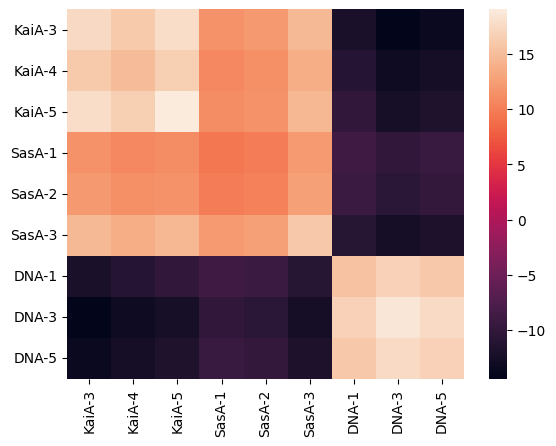

In [ ]:
sns.heatmap(A_mh_df)

(9,)

ValueError: Unable to coerce to DataFrame, shape must be (167, 9): given (9, 9)

In [ ]:
mvnorm_traj.shape

(9, 9)